##### Import statements:

In [112]:
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from analysis_metadata.analysis_metadata import Metadata, increment_dir_name, write_metadata

##### Define inputs, parameters:

In [105]:
# Input file:
input_path = os.path.join('/', 'mnt', 'smb', 'locker', 'issa-locker', 'users', 'Dan', 'code', 'ws', 'results', 'run791', 'tngl_pred.pickle')
input_dir = os.path.split(input_path)[0]

# Output parameters:
save_output = True

##### Load previously-saved results:

In [106]:
tngl_pred_out = pickle.load(open(input_path, 'rb'))

In [81]:
tngl_pred_out['geo_df'].parallelism

0      0.758108
1      0.758108
2      0.272513
3      0.272513
4      0.411976
         ...   
539   -0.015307
540   -0.288938
541   -0.288938
542   -0.396413
543   -0.396413
Name: parallelism, Length: 544, dtype: float64

##### Find max training epoch for all model instances:

##### Find aymptotic participation ratio for all models:

In [115]:
loss_df = tngl_pred_out['ae_df']
loss_df_ae = loss_df[loss_df.mdl_type=='autoencoder']
loss_pr_df = loss_df_ae[['tngl_mdl_id', 'epoch', 'loss_pr']].groupby('tngl_mdl_id').apply(lambda x : x[x.epoch==np.max(x.epoch)].loss_pr)
loss_pr_df = pd.DataFrame(loss_pr_df).reset_index().drop(columns='level_1')

In [108]:
loss_pr_df

,tngl_mdl_id,loss_pr
0,OdlPvqCBJd,46.893841
1,TKkfGgfHeU,76.354156
2,sKTWPaZcyA,76.022758
3,wjIELY07sz,73.146362


##### Compute mean asymptotic paralellism score across repeats for each prediction model:

In [120]:
# Get dataframe of geometry results for prediction model:
geo_df = tngl_pred_out['geo_df']
geo_df_pred = geo_df[geo_df.mdl_type=='prediction']
print(geo_df_pred.shape)


# Find final training epoch for all models:
max_epoch_df = geo_df_pred[['tngl_mdl_id', 'epoch']].groupby('tngl_mdl_id').apply(lambda x : np.max(x.epoch)).reset_index(name='epoch')
max_epoch_df = pd.DataFrame(max_epoch_df)

# Select only results for final training epoch:
geo_df_pred = pd.merge(geo_df_pred, max_epoch_df, on=['tngl_mdl_id', 'epoch'])

# Average across repeats:
Mu_pred = geo_df_pred[['tngl_mdl_id', 'parallelism']].groupby('tngl_mdl_id').mean().reset_index()

# Merge with PR loss:
Mu_pred = pd.merge(Mu_pred, loss_pr_df, on='tngl_mdl_id')

(480, 73)


In [125]:
geo_df_ae = geo_df[geo_df.mdl_type=='autoencoder']

# Find final training epoch for all models:
max_epoch_df = geo_df_ae[['tngl_mdl_id', 'epoch']].groupby('tngl_mdl_id').apply(lambda x : np.max(x.epoch)).reset_index(name='epoch')
max_epoch_df = pd.DataFrame(max_epoch_df)

# Select only results for final training epoch:
geo_df_ae = pd.merge(geo_df_ae, max_epoch_df, on=['tngl_mdl_id', 'epoch'])

# Average across repeats:
Mu_ae = geo_df_ae[['tngl_mdl_id', 'parallelism']].groupby('tngl_mdl_id').mean().reset_index()

# Merge with PR loss:
Mu_ae = pd.merge(Mu_ae, loss_pr_df, on='tngl_mdl_id')

In [110]:
Mu

,tngl_mdl_id,parallelism,loss_pr
0,OdlPvqCBJd,0.190764,46.893841
1,TKkfGgfHeU,0.129650,76.354156
2,sKTWPaZcyA,0.182462,76.022758
3,wjIELY07sz,0.288129,73.146362


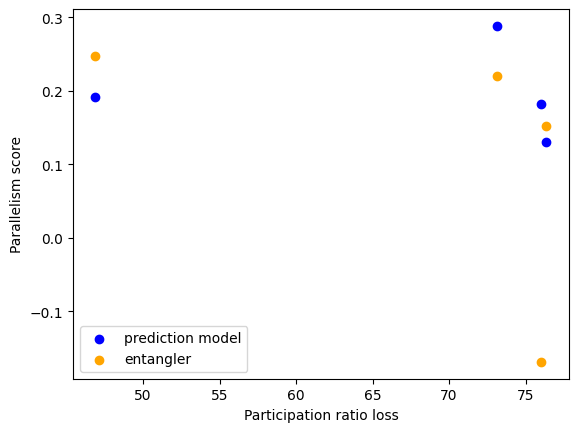

In [126]:
plt.scatter(Mu_pred.loss_pr, Mu_pred.parallelism, color='blue', label='prediction model')
plt.scatter(Mu_ae.loss_pr, Mu_ae.parallelism, color='orange', label='entangler')
plt.ylabel('Parallelism score')
plt.xlabel('Participation ratio loss')
plt.legend()

In [124]:
Mu_ae.columns

Index(['tngl_mdl_id', 'parallelism_x', 'index_x', 'dichotomy',
       'train_partition', 'train_accuracy', 'test_accuracy', 'parallelism_y',
       'layer', 'epoch', 'model_type', 'dichotomy_idx', 'train_partition_inds',
       'mdl_type', 'n_hidden', 'beta_rec', 'beta_pr', 'beta_sp', 'n_epochs',
       'batch_size', 'lr', 'p_norm', 'sig_init', 'sig_neu', 'beta0', 'beta1',
       'beta_xor', 'n_predictor_bins', 'n_predicted_bins', 'noise_w',
       'task_defs', 'ini_phase_spr', 'inir_position', 'verbose', 'save_perf',
       'n_files', 'save_sessions', 'std_reset', 'n_splits', 'n_offsets',
       'n_whisk', 't_total', 'save_learning', 'steps_mov', 'z1', 'delay_time',
       'dx', 'xor', 'disp', 'n_rad', 'speed', 'spread', 'zscore_data',
       'freq_sh', 'gpu', 'prob_poiss', 'freq_m', 'amp', 'freq_std',
       'n_geo_subsamples', 'sum_inpt', 'rad_vec', 'theta', 'dt',
       'n_trials_pre', 'repeat_idx_within_run', 'init_position', 'max_rad',
       'chunked_reconstruction_loss', 'conca